<a href="https://colab.research.google.com/github/hrulevskaya/ML_tasks/blob/main/6task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# # Подключаем наш гугл диск к блокноту
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import sys, os
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import torch
print(torch.__version__)

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import torchvision.models as models
import torch._dynamo
torch._dynamo.config.suppress_errors = True

2.10.0+cu128


In [ ]:
batch_size = 16
use_cuda = torch.cuda.is_available()
print(use_cuda)

torch.manual_seed(1)

INPUT_SIZE=224
preprocess=transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(INPUT_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
    ])

train_dataset = datasets.ImageFolder(root="/content/gdrive/MyDrive/small/train", transform=preprocess)
test_dataset = datasets.ImageFolder(root="/content/gdrive/MyDrive/small/test", transform=preprocess)
val_dataset = datasets.ImageFolder(root="/content/gdrive/MyDrive/small/validation", transform=preprocess)

kwargs = {'num_workers': 1, 'pin_memory': True} if use_cuda else {}

train_loader = torch.utils.data.DataLoader(train_dataset,batch_size=batch_size, shuffle=True, **kwargs)
val_loader = torch.utils.data.DataLoader(val_dataset,batch_size=batch_size, shuffle=False, **kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=batch_size, shuffle=False, **kwargs)

True


In [ ]:
from tqdm import tqdm


def train(model, device, train_loader, optimizer, epoch):
  train_loss = 0.0
  total_train = 0
  correct_train = 0
  model.train()
  for batch_idx, (data, target) in enumerate(tqdm(train_loader)):
      data, target = data.to(device), target.to(device).to(torch.float32)
      optimizer.zero_grad()
      output = model(data)
      loss = F.binary_cross_entropy(output, target)
      loss.backward()
      optimizer.step()
      if batch_idx % 10 == 0:
        display('Train Epoch: {} [{}/{} ({:.0f}%)] Loss: {:.6f}'.format(
            epoch, batch_idx * len(data), len(train_loader.dataset),
            100. * batch_idx / len(train_loader), loss.item()), display_id=str(epoch), update=True)

      # accuracy
      predicted = torch.round(output.data)
      train_loss += loss.item()
      total_train += target.nelement()  # number of pixel in the batch
      correct_train += predicted.eq(target.data).sum().item() # sum all precited pixel values

  epoch_loss = train_loss / len(train_loader.dataset)
  epoch_acc = 100.*(correct_train / total_train)
  print('Train set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)'.format(
      epoch_loss,correct_train, total_train, epoch_acc))
  return epoch_loss,epoch_acc

def test(model, device, test_loader):
  model.eval()
  test_loss = 0
  correct = 0
  with torch.no_grad(): #отключает вычисление градиентов и построение вычислительного графа для экономии памяти
      for data, target in tqdm(test_loader):
          data, target = data.to(device), target.to(device).to(torch.float32)
          output = model(data)
          test_loss += F.binary_cross_entropy(output, target).item()  # sum up batch loss
          pred = torch.round(output)  # get the index of the max log-probability
          correct += pred.eq(target.view_as(pred)).sum().item()

  test_loss /= len(test_loader.dataset)
  accuracy=100. * correct / len(test_loader.dataset)

  print('Val set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)'.format(
      test_loss, correct, len(test_loader.dataset),
      accuracy))
  return test_loss,accuracy

1. Адаптировать код MNIST под задачу бинарной классификации

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.act = nn.Tanh()

        self.convs = nn.ModuleList()
        self.convs.append(nn.Conv2d(3, 32, (5, 5)))
        for _ in range(4):
            self.convs.append(nn.Conv2d(32, 32, (5, 5)))

        self.pool = nn.MaxPool2d((2, 2))

        self.linears = nn.ModuleList()
        self.linears.append(nn.Linear(288, 256))
        for _ in range(3):
            self.linears.append(nn.Linear(256, 256))
        self.linears.append(nn.Linear(256, 1))

    def forward(self, x):
        for conv in self.convs:
            x = conv(x)
            x = self.act(x)
            x = self.pool(x)

        x = x.view(x.shape[0], -1)

        for fc in self.linears[:-1]:
            x = fc(x)
            x = self.act(x)

        x = self.linears[-1](x).squeeze(-1)

        output = F.sigmoid(x)
        return output


In [ ]:
epochs = 20
device = torch.device("cuda" if use_cuda else "cpu")

model = Net().to(device)
model=torch.compile(model) #PyTorch
optimizer = optim.AdamW(model.parameters(), lr=0.01)
scheduler = StepLR(optimizer, step_size=2, gamma=0.7)
train_accuracies,val_accuracies=[],[]
for epoch in range(1, epochs + 1):
    print("Epoch", epoch)
    train_loss,train_accuracy=train(model, device, train_loader, optimizer, epoch)
    train_accuracies.append(train_accuracy)
    val_loss,val_accuracy=test(model, device, val_loader)
    val_accuracies.append(val_accuracy)
    scheduler.step()

Epoch 1


  0%|          | 0/33 [00:00<?, ?it/s]W0521 22:03:02.231000 3747 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


'Train Epoch: 1 [480/528 (91%)] Loss: 0.703661'

100%|██████████| 33/33 [01:45<00:00,  3.20s/it]


Train set: Average loss: 0.0516, Accuracy: 266/528 (50%)


...

'Train Epoch: 20 [480/528 (91%)] Loss: 0.654586'

100%|██████████| 33/33 [00:04<00:00,  8.05it/s]


Train set: Average loss: 0.0426, Accuracy: 295/528 (56%)


100%|██████████| 16/16 [00:01<00:00,  8.56it/s]

Val set: Average loss: 0.0433, Accuracy: 127/256 (50%)


20 20


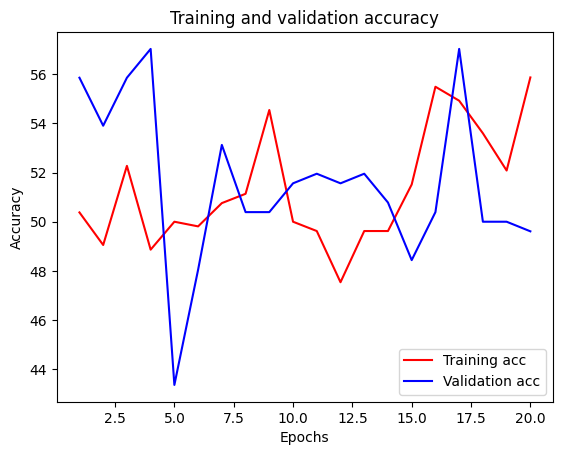

In [ ]:
print(len(train_accuracies),len(val_accuracies))
epochs = range(1, len(train_accuracies) + 1)

plt.plot(epochs, train_accuracies, 'r', label='Training acc')
plt.plot(epochs, val_accuracies, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
score = test(model, device, test_loader)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

100%|██████████| 16/16 [01:11<00:00,  4.50s/it]

Val set: Average loss: 0.0431, Accuracy: 140/256 (55%)
Test loss: 0.043121129274368286
Test accuracy: 54.6875


2. Использовать предобученную сеть для извлечения фич.

In [ ]:
cnn_model = models.mobilenet_v2(pretrained=True)
featureExtractor=cnn_model.features
featureExtractor.eval().to(device)

def extract_features(x):
    with torch.no_grad():
        return featureExtractor(x)

class Net2(nn.Module):
    def __init__(self):
        super(Net2, self).__init__()
        self.act = nn.Tanh()

        self.conv = nn.Conv2d(1280, 512, (7, 7))

        self.linears = nn.ModuleList()
        self.linears.append(nn.Linear(512, 256))
        for _ in range(3):
            self.linears.append(nn.Linear(256, 256))
        self.linears.append(nn.Linear(256, 1))

    def forward(self, x):
        x = extract_features(x)

        x = self.conv(x)
        x = self.act(x)

        x = x.view(x.shape[0], -1)

        for fc in self.linears[:-1]:
            x = fc(x)
            x = self.act(x)

        x = self.linears[-1](x).squeeze(-1)

        output = F.sigmoid(x)
        return output


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 132MB/s]


In [ ]:
epochs = 20
device = torch.device("cuda" if use_cuda else "cpu")

model = Net2().to(device)
# model=torch.compile(model) #PyTorch
optimizer = optim.AdamW(model.parameters(), lr=0.01)
scheduler = StepLR(optimizer, step_size=2, gamma=0.7)
train_accuracies,val_accuracies=[],[]
for epoch in range(1, epochs + 1):
    print("Epoch", epoch)
    train_loss,train_accuracy=train(model, device, train_loader, optimizer, epoch)
    train_accuracies.append(train_accuracy)
    val_loss,val_accuracy=test(model, device, val_loader)
    val_accuracies.append(val_accuracy)
    scheduler.step()

Epoch 1


  0%|          | 0/33 [00:00<?, ?it/s]

'Train Epoch: 1 [480/528 (91%)] Loss: 0.622463'

100%|██████████| 33/33 [00:04<00:00,  7.80it/s]


Train set: Average loss: 0.0590, Accuracy: 268/528 (51%)


...

'Train Epoch: 20 [480/528 (91%)] Loss: 0.715442'

100%|██████████| 33/33 [00:05<00:00,  5.88it/s]


Train set: Average loss: 0.0437, Accuracy: 252/528 (48%)


100%|██████████| 16/16 [00:01<00:00,  8.70it/s]

Val set: Average loss: 0.0437, Accuracy: 128/256 (50%)


20 20


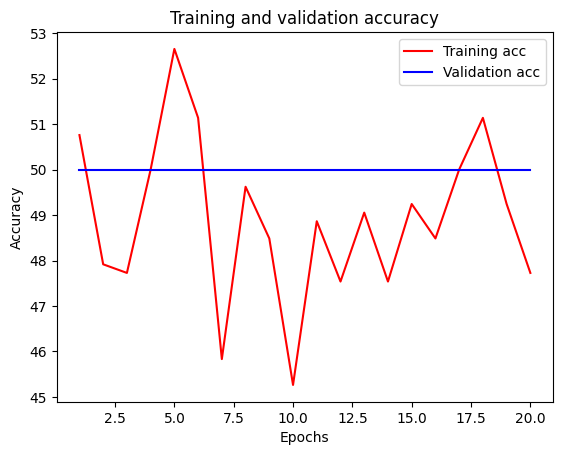

In [ ]:
print(len(train_accuracies),len(val_accuracies))
epochs = range(1, len(train_accuracies) + 1)

plt.plot(epochs, train_accuracies, 'r', label='Training acc')
plt.plot(epochs, val_accuracies, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
score = test(model, device, test_loader)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

100%|██████████| 16/16 [00:01<00:00,  8.52it/s]

Val set: Average loss: 0.0437, Accuracy: 128/256 (50%)
Test loss: 0.04370582429692149
Test accuracy: 50.0


Первый подход (адаптация кода MNIST) показал точность 54.7%, второй (извлечение признаков) — 50.0%. Потери на тестовой выборке практически одинаковы (~0.043). Таким образом, адаптация кода MNIST даёт небольшое преимущество в точности по сравнению с использованием предобученной сети для извлечения признаков.